<a href="https://colab.research.google.com/github/shahriarSwanon/Image-classification/blob/main/KNN_Animal_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# YOUR DATASET PATH
DATASET_PATH = '/content/drive/MyDrive/KNN_Animal_Classifier/data'
CATEGORIES = ['cat', 'cow', 'dog', 'lamb', 'zebra']
IMG_SIZE = (64, 64)
BINS = 32  # Number of bins for color histogram
SEED = 42

np.random.seed(SEED)

# Verify dataset
print("Verifying dataset...")
for cat in CATEGORIES:
    folder = os.path.join(DATASET_PATH, cat)
    if os.path.exists(folder):
        count = len([f for f in os.listdir(folder) if f.endswith(('.jpg','.png','.jpeg'))])
        print(f"  {cat}: {count} images")
    else:
        print(f"  {cat}: FOLDER NOT FOUND!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Verifying dataset...
  cat: 111 images
  cow: 101 images
  dog: 105 images
  lamb: 107 images
  zebra: 108 images


In [8]:
def load_and_resize_image(path, size=IMG_SIZE):
    """Load image and resize using simple indexing (no OpenCV)"""
    img = plt.imread(path)

    # Handle different image formats
    if img.dtype in [np.float32, np.float64]:
        img = (img * 255).astype(np.uint8)

    # Simple resize using numpy indexing
    old_h, old_w = img.shape[:2]
    row_idx = (np.linspace(0, old_h-1, size[0])).astype(int)
    col_idx = (np.linspace(0, old_w-1, size[1])).astype(int)

    if len(img.shape) == 2:  # Grayscale
        img = np.stack([img, img, img], axis=2)

    return img[row_idx[:, None], col_idx]

def horizontal_flip(img):
    """Flip image horizontally"""
    return np.fliplr(img)

def rotate_90(img, k=1):
    """Rotate image by 90 degrees k times"""
    return np.rot90(img, k)

def extract_color_histogram(img, bins=BINS):
    """Extract normalized color histogram features"""
    features = []
    for channel in range(3):  # R, G, B
        hist, _ = np.histogram(img[:, :, channel], bins=bins, range=(0, 256))
        hist = hist / (np.sum(hist) + 1e-8)  # Normalize
        features.extend(hist)
    return np.array(features)

def load_dataset_with_augmentation(dataset_path, categories, augment=True):
    """Load images and extract features with optional augmentation"""
    X = []
    y = []

    for label, category in enumerate(categories):
        folder = os.path.join(dataset_path, category)
        print(f"Loading {category}...")

        images = [f for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for img_name in images[:100]:  # Take 100 images per class
            try:
                img_path = os.path.join(folder, img_name)
                img = load_and_resize_image(img_path)

                # Original image
                X.append(extract_color_histogram(img))
                y.append(label)

                if augment:
                    # Flipped image
                    X.append(extract_color_histogram(horizontal_flip(img)))
                    y.append(label)

                    # Rotated image (90 degrees)
                    X.append(extract_color_histogram(rotate_90(img, 1)))
                    y.append(label)

            except Exception as e:
                continue

    return np.array(X), np.array(y)

print("Functions defined successfully!")

Functions defined successfully!


In [9]:
print("Loading dataset with augmentation...")
X, y = load_dataset_with_augmentation(DATASET_PATH, CATEGORIES, augment=True)
print(f"\n✓ Loaded {X.shape[0]} total samples (each image gives 3 variations)")
print(f"✓ Each sample has {X.shape[1]} features ({BINS} bins × 3 channels)")
print(f"✓ Number of classes: {len(np.unique(y))}")

# Normalize features (standardization)
mean = X.mean(axis=0)
std = X.std(axis=0) + 1e-8
X = (X - mean) / std

print("✓ Features standardized")

# Train/validation/test split (70% train, 10% val, 20% test)
indices = np.random.permutation(len(X))
train_end = int(0.7 * len(X))
val_end = int(0.8 * len(X))

X_train, y_train = X[indices[:train_end]], y[indices[:train_end]]
X_val, y_val = X[indices[train_end:val_end]], y[indices[train_end:val_end]]
X_test, y_test = X[indices[val_end:]], y[indices[val_end:]]

print(f"\nSplit sizes:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test: {X_test.shape[0]} samples")

Loading dataset with augmentation...
Loading cat...
Loading cow...
Loading dog...
Loading lamb...
Loading zebra...

✓ Loaded 1500 total samples (each image gives 3 variations)
✓ Each sample has 96 features (32 bins × 3 channels)
✓ Number of classes: 5
✓ Features standardized

Split sizes:
  Training: 1050 samples
  Validation: 150 samples
  Test: 300 samples


In [10]:
def apply_pca(X, explained_variance=0.95):
    """Manual PCA implementation"""
    # Center the data
    mean = X.mean(axis=0)
    X_centered = X - mean

    # Compute covariance matrix
    cov = np.cov(X_centered, rowvar=False)

    # Compute eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort in descending order
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Find number of components to retain explained_variance
    total_var = np.cumsum(eigvals) / np.sum(eigvals)
    n_components = np.searchsorted(total_var, explained_variance) + 1

    # Keep top components
    top_vecs = eigvecs[:, :n_components]

    # Project data
    X_reduced = X_centered @ top_vecs

    return X_reduced, mean, top_vecs

# Find best PCA variance using validation set
print("Finding optimal PCA variance...")
best_acc = 0
best_var = 95  # Default

# Quick way: try common variance values
for var in [85, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]:
    X_train_pca, pca_mean, pca_vecs = apply_pca(X_train, explained_variance=var/100)
    X_val_pca = (X_val - pca_mean) @ pca_vecs

    # Quick KNN with k=sqrt(n)
    k_default = int(np.sqrt(len(X_train_pca)))
    if k_default % 2 == 0:
        k_default += 1

    # Manual KNN prediction
    dists = np.sqrt(((X_val_pca[:, None, :] - X_train_pca[None, :, :])**2).sum(axis=2))
    nearest = np.argsort(dists, axis=1)[:, :k_default]
    y_val_pred = np.array([np.bincount(y_train[n]).argmax() for n in nearest])

    acc = np.mean(y_val_pred == y_val) * 100

    if acc > best_acc:
        best_acc = acc
        best_var = var

print(f"✓ Best PCA variance: {best_var}% (validation accuracy: {best_acc:.2f}%)")

# Apply best PCA
FIXED_PCA_VARIANCE = best_var / 100
X_train_pca, pca_mean, pca_vecs = apply_pca(X_train, explained_variance=FIXED_PCA_VARIANCE)
X_val_pca = (X_val - pca_mean) @ pca_vecs
X_test_pca = (X_test - pca_mean) @ pca_vecs

print(f"✓ PCA reduced features from {X_train.shape[1]} to {X_train_pca.shape[1]} dimensions")

Finding optimal PCA variance...
✓ Best PCA variance: 85% (validation accuracy: 54.00%)
✓ PCA reduced features from 96 to 19 dimensions



Validation Accuracy for each k:
  k= 1 -> Validation Accuracy: 94.67%
  k= 3 -> Validation Accuracy: 70.00%
  k= 5 -> Validation Accuracy: 49.33%
  k= 7 -> Validation Accuracy: 56.67%
  k= 9 -> Validation Accuracy: 54.67%
  k=11 -> Validation Accuracy: 52.67%
  k=13 -> Validation Accuracy: 53.33%
  k=15 -> Validation Accuracy: 48.67%
  k=17 -> Validation Accuracy: 47.33%
  k=19 -> Validation Accuracy: 48.67%
  k=21 -> Validation Accuracy: 51.33%
  k=23 -> Validation Accuracy: 48.67%
  k=25 -> Validation Accuracy: 50.67%
  k=27 -> Validation Accuracy: 51.33%
  k=29 -> Validation Accuracy: 50.67%

✓ Best k (from validation) = 1, Validation Accuracy = 94.67%


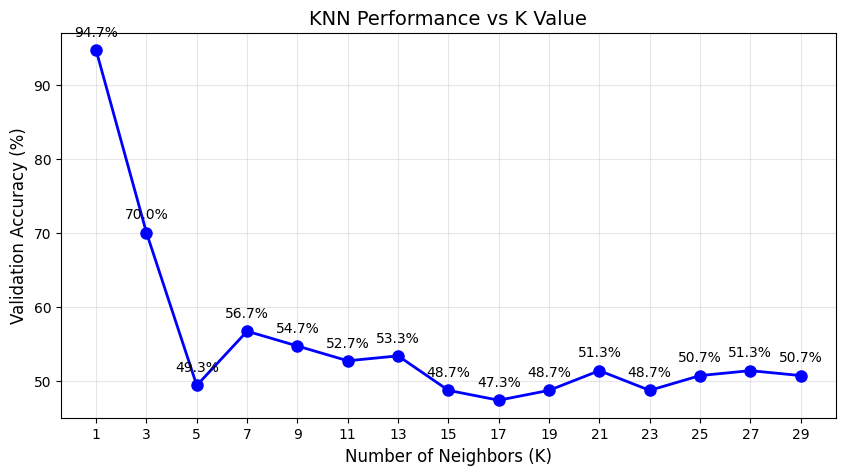

In [11]:
def knn_predict(X_train, y_train, X_test, k):
    """Manual KNN prediction"""
    # Compute Euclidean distances
    # Using broadcasting for efficiency
    dists = np.sqrt(((X_test[:, None, :] - X_train[None, :, :])**2).sum(axis=2))

    # Find k nearest neighbors
    nearest = np.argsort(dists, axis=1)[:, :k]

    # Majority vote
    predictions = np.array([np.bincount(y_train[n]).argmax() for n in nearest])

    return predictions

# Tune k using validation set
max_k = int(np.sqrt(len(X_train_pca)))
if max_k % 2 == 0:
    max_k += 1

k_values = list(range(1, min(max_k, 31), 2))  # Odd k values up to 31
accuracies = []

print("\nValidation Accuracy for each k:")
for k in k_values:
    y_val_pred = knn_predict(X_train_pca, y_train, X_val_pca, k)
    acc = np.mean(y_val_pred == y_val) * 100
    accuracies.append(acc)
    print(f"  k={k:2d} -> Validation Accuracy: {acc:.2f}%")

best_k_idx = np.argmax(accuracies)
best_k = k_values[best_k_idx]
best_val_acc = accuracies[best_k_idx]

print(f"\n✓ Best k (from validation) = {best_k}, Validation Accuracy = {best_val_acc:.2f}%")

# Plot accuracy vs K
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.title('KNN Performance vs K Value', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
for i, (k, acc) in enumerate(zip(k_values, accuracies)):
    plt.annotate(f'{acc:.1f}%', (k, acc), textcoords="offset points", xytext=(0, 10), ha='center')
plt.show()


FINAL MODEL PERFORMANCE
✓ Best K value: 1
✓ PCA variance retained: 85%
✓ Test Accuracy: 93.67%

NUMERIC CONFUSION MATRIX
Rows: True Label, Columns: Predicted Label

       cat   cow   dog   lamb  zebra
cat      [54  0  3  0  0]
cow      [ 2 48  0  0  0]
dog      [ 0  0 56  3  5]
lamb     [ 0  0  0 56  2]
zebra    [ 0  0  2  2 67]


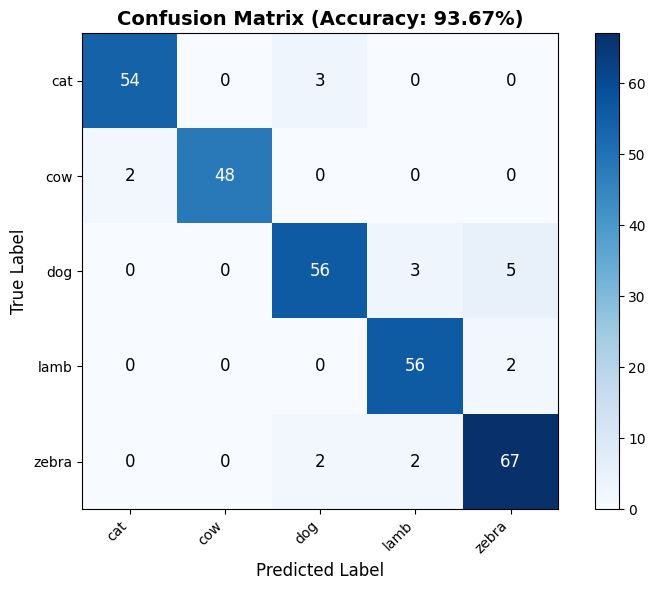


CLASSIFICATION REPORT
Class        Precision  Recall  F1-Score  Support
----------------------------------------------
cat              96.43   94.74     95.58       57
cow             100.00   96.00     97.96       50
dog              91.80   87.50     89.60       64
lamb             91.80   96.55     94.12       58
zebra            90.54   94.37     92.41       71
----------------------------------------------
Avg/Total        94.12   93.83     93.97      300


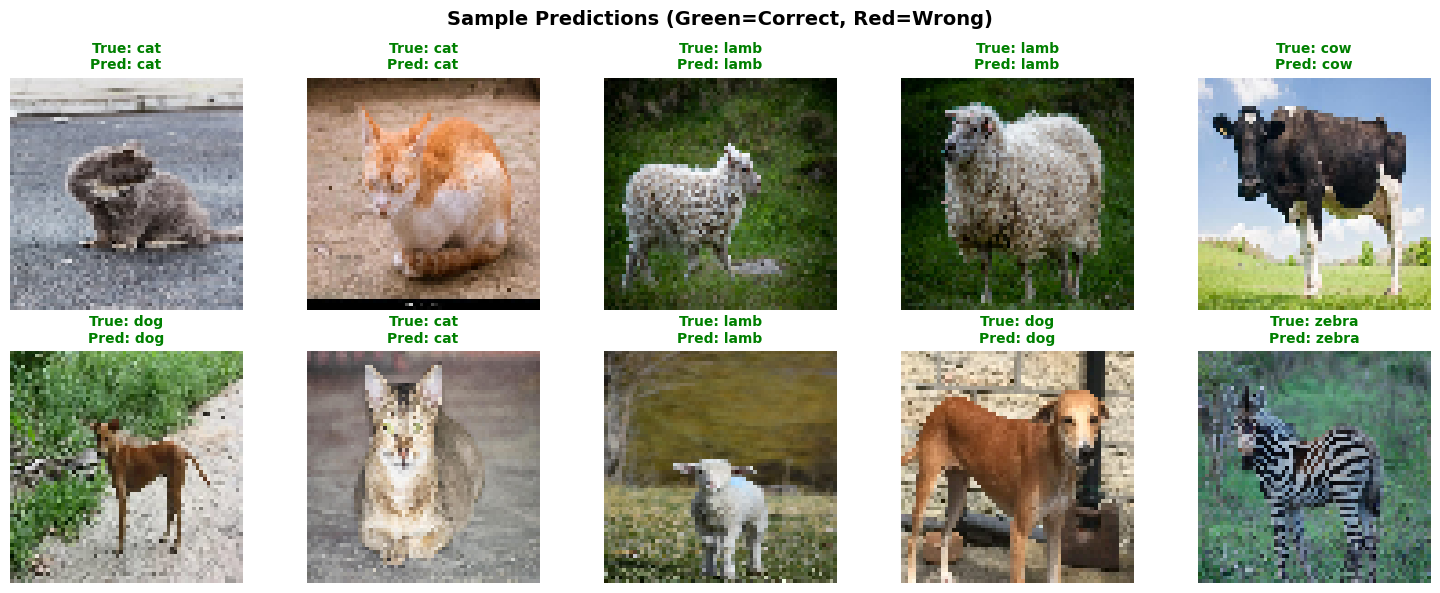

In [13]:
# Predict on test set
y_test_pred = knn_predict(X_train_pca, y_train, X_test_pca, best_k)
test_accuracy = np.mean(y_test_pred == y_test) * 100

print(f"\n{'='*50}")
print(f"FINAL MODEL PERFORMANCE")
print(f"{'='*50}")
print(f"✓ Best K value: {best_k}")
print(f"✓ PCA variance retained: {best_var}%")
print(f"✓ Test Accuracy: {test_accuracy:.2f}%")

# ================= CONFUSION MATRIX =================
def confusion_matrix(y_true, y_pred, num_classes=5):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

cm = confusion_matrix(y_test, y_test_pred)

# Print numeric confusion matrix
print(f"\n{'='*50}")
print("NUMERIC CONFUSION MATRIX")
print(f"{'='*50}")
print("Rows: True Label, Columns: Predicted Label\n")
print("       " + "  ".join(f"{cat:4s}" for cat in CATEGORIES))
for i, cat in enumerate(CATEGORIES):
    print(f"{cat:8s} {str(cm[i])}")

# ================= VISUAL CONFUSION MATRIX HEATMAP =================
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

# Show values in each cell
for i in range(len(CATEGORIES)):
    for j in range(len(CATEGORIES)):
        text = ax.text(j, i, cm[i, j],
                       ha="center", va="center",
                       color="white" if cm[i, j] > cm.max()/2 else "black",
                       fontsize=12)

ax.set_xticks(np.arange(len(CATEGORIES)))
ax.set_yticks(np.arange(len(CATEGORIES)))
ax.set_xticklabels(CATEGORIES, rotation=45, ha="right")
ax.set_yticklabels(CATEGORIES)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title(f"Confusion Matrix (Accuracy: {test_accuracy:.2f}%)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ================= CLASSIFICATION REPORT =================
print(f"\n{'='*50}")
print("CLASSIFICATION REPORT")
print(f"{'='*50}")
print(f"{'Class':<12} {'Precision':>9} {'Recall':>7} {'F1-Score':>9} {'Support':>8}")
print("-" * 46)

for i, cat in enumerate(CATEGORIES):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp
    support = np.sum(cm[i, :])

    precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"{cat:<12} {precision:9.2f} {recall:7.2f} {f1:9.2f} {support:8}")

# Calculate averages
avg_precision = np.mean([cm[i,i]/np.sum(cm[:,i])*100 if np.sum(cm[:,i])>0 else 0 for i in range(5)])
avg_recall = np.mean([cm[i,i]/np.sum(cm[i,:])*100 for i in range(5)])
avg_f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall)

print("-" * 46)
print(f"{'Avg/Total':<12} {avg_precision:9.2f} {avg_recall:7.2f} {avg_f1:9.2f} {np.sum(cm):8}")
print(f"{'='*50}")

# ================= VISUALIZE SAMPLE PREDICTIONS =================
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Load some test images for display
test_samples = []
for label, cat in enumerate(CATEGORIES):
    folder = os.path.join(DATASET_PATH, cat)
    images = [f for f in os.listdir(folder) if f.endswith(('.jpg','.png','.jpeg'))]
    for img_name in images[:5]:  # Get 5 per class
        test_samples.append((os.path.join(folder, img_name), label))

# Randomly select 10
import random
random.shuffle(test_samples)
display_samples = test_samples[:10]

for i, (img_path, true_label) in enumerate(display_samples):
    img = load_and_resize_image(img_path)

    # Extract features and predict
    features = extract_color_histogram(img)
    features = (features - mean) / std
    features_pca = (features - pca_mean) @ pca_vecs
    pred_label = knn_predict(X_train_pca, y_train, features_pca.reshape(1, -1), best_k)[0]

    axes[i].imshow(img)
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'True: {CATEGORIES[true_label]}\nPred: {CATEGORIES[pred_label]}',
                      fontsize=10, color=color, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()